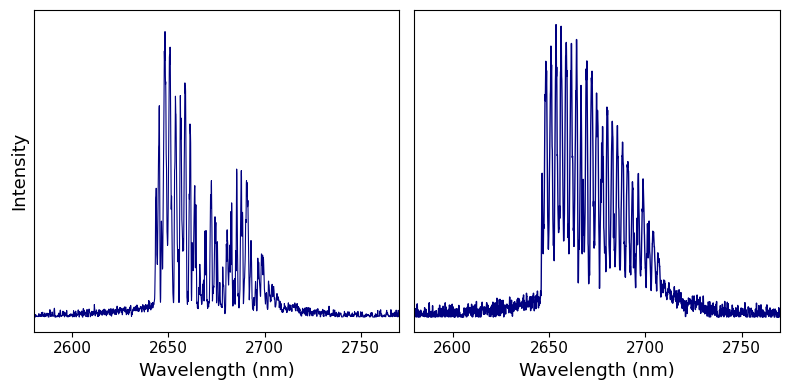

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# === USER INPUT ===
file_air = "FirstPurging/BeforePurging/2770nm_04_0.51nm.txt"
file_nitrogen = "FirstPurging/PurgedCut/2770nm_90min_cut_0.41nm.txt"

# wavelength range (in nm)
xmin = 2580.0
xmax = 2770.0

# === LOAD DATA ===
# assumes delimiter is ";" like in your screenshot
data_air = np.loadtxt(file_air, delimiter=";")
data_nitrogen = np.loadtxt(file_nitrogen, delimiter=";")

wl_air, int_air = data_air[:, 0], data_air[:, 1]
wl_nit, int_nit = data_nitrogen[:, 0], data_nitrogen[:, 1]

# === FILTER RANGE ===
mask_air = (wl_air >= xmin) & (wl_air <= xmax)
mask_nit = (wl_nit >= xmin) & (wl_nit <= xmax)

wl_air_f, int_air_f = wl_air[mask_air], int_air[mask_air]
wl_nit_f, int_nit_f = wl_nit[mask_nit], int_nit[mask_nit]

# === PLOT ===
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].plot(wl_air_f, int_air_f, linewidth=0.8, color='navy')
axes[0].set_xlabel("Wavelength (nm)", fontsize=13)
axes[0].set_ylabel("Intensity", fontsize=13)

axes[1].plot(wl_nit_f, int_nit_f * 1.4, linewidth=1, color='navy')
axes[1].set_xlabel("Wavelength (nm)", fontsize=13)

axes[0].tick_params(axis='x', labelsize=11)
axes[1].tick_params(axis='x', labelsize=11)

for ax in axes:
    ax.set_yticks([])
    ax.set_yticklabels([])

plt.xlim(xmin, xmax)
plt.tight_layout()
plt.savefig("cut_spectra_purging.pdf")
plt.show()